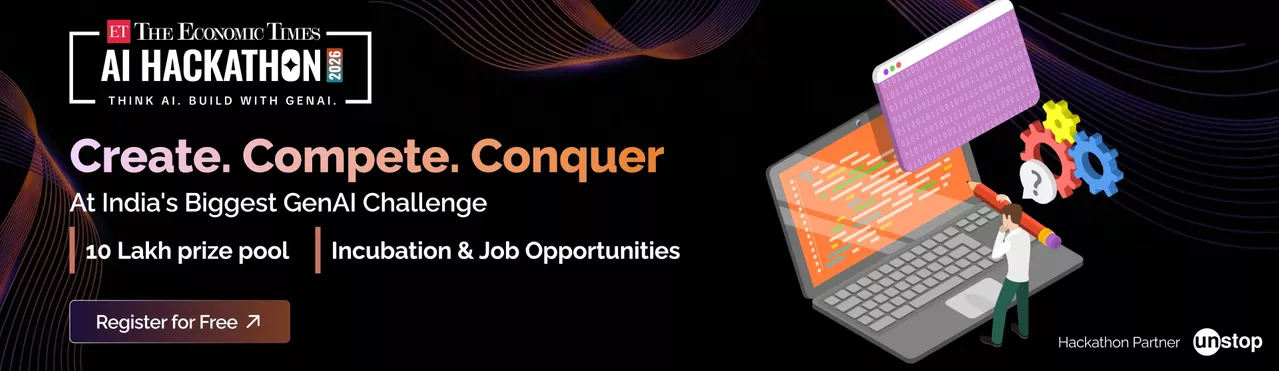


---

## **Problem Statement :- 9**

*95% of Indians don't have a financial plan. **Financial advisors charge ₹25,000+ per year** and serve only High Net-worth Individuals (HNIs). Build an AI-powered **personal finance mentor** that lives inside ET, turns confused savers into confident investors, and makes financial planning as accessible as **checking WhatsApp**.*


* **WHAT YOU MAY BUILD**


  • Financial Independence, Retire Early (FIRE) Path Planner — User inputs age, income, expenses, existing investments, and life goals. AI builds a complete, month-by-month financial roadmap: Systematic Investment Plan (SIP) amounts per goal, asset allocation shifts, insurance gaps, tax-saving moves, and emergency fund targets.

#### **Prototype built-up by :- AI Devilops**

*Team Lead and member - Deepak Kaura*

### ***Libraries to install before run the Gradio UI***

In [1]:
!pip install -U langchain langchain-core langchain-community

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 112.5/112.5 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 506.7/506.7 kB 16.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 28.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 31.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.0/65.0 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.0/51.0 kB 2.9 MB/s eta 0:00:00
  Attempting uninstall: requests
    Found existing installation: requests 2.32.4
    Uninstalling requests-2.32.4:
      Successfully uninstalled requests-2.32.4
  Attempting uninstall: langchain-core
    Found existing installation: langchain-core 1.2.19
    Uninstalling langchain-core-1.2.19:
      Successfully uninstalled langchain-core-1.2.19
  Attempting uninstall: langchain
    Found existing installation: langchain 1.2.12
    Uninstalling langchain-1.2.12:
      Successfully uninstalled langchain-1.2.12
ERROR: pip's

In [2]:
!pip install txtai[pipeline]

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.0/59.0 MB 17.5 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Installing backend dependencies ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.1/68.1 kB 5.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.6/162.6 kB 12.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
INFO: pip is looking at multiple versions of transformers to determine which version is compatible with other requirements. This could take a while.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 15.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 233.0/233.0 kB 17.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 446.3/446.3 kB 30.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 69.4 MB/s et

#### **Run this to load the model**

In [3]:
from txtai.pipeline import LLM as TxtaiLLM

txtai_llm = TxtaiLLM("LiteLLMs/gemma-2b-it-GGUF/Q8_0/Q8_0-00001-of-00001.gguf")

[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger.zip.
[nltk_data] Downloading package cmudict to /root/nltk_data...
[nltk_data]   Unzipping corpora/cmudict.zip.
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Q8_0/Q8_0-00001-of-00001.gguf:   0%|          | 0.00/2.67G [00:00<?, ?B/s]

#### **Semi-Deployment**

In [ ]:
# =========================
# Imports
# =========================
from langchain_core.prompts import PromptTemplate
from langchain_core.output_parsers import StrOutputParser
from txtai.pipeline import LLM as TxtaiLLM
from langchain_core.language_models.llms import BaseLLM as LangChainLLM
from langchain_core.outputs import LLMResult, Generation

import pandas as pd
from typing import List, Optional, Any

# =========================
# LLM Setup
# =========================
txtai_llm_instance = TxtaiLLM(
    "LiteLLMs/gemma-2b-it-GGUF/Q8_0/Q8_0-00001-of-00001.gguf"
)

class TxtaiLangChainLLM(LangChainLLM):
    def _generate(self, prompts: List[str], stop: Optional[List[str]] = None, **kwargs: Any) -> LLMResult:
        generations = []
        for prompt in prompts:
            response = txtai_llm_instance(prompt)
            generations.append([Generation(text=response)])
        return LLMResult(generations=generations)

    @property
    def _llm_type(self) -> str:
        return "txtai"

llm = TxtaiLangChainLLM()

# =========================
# FIRE Score
# =========================
def calculate_fire_score(user, depletion_age, shortfall):
    score = 0
    # FIRE standard: Ideally savings rate should be > 50%
    score += 25 if user["savings_rate"] >= 0.5 else 15 if user["savings_rate"] >= 0.3 else 5
    score += 25 if depletion_age >= 90 else 15 if depletion_age >= 80 else 5
    score += 15 if user["return"] >= 0.12 else 8
    score += 10 if user["inflation"] <= 0.06 else 5
    score += 25 if shortfall <= 0 else 0
    return score

def get_score_bucket(score):
    if score < 40:
        return "Critical"
    elif score < 60:
        return "Weak"
    elif score < 75:
        return "Moderate"
    elif score < 90:
        return "Strong"
    else:
        return "Optimized"

# =========================
# SIP Calculation
# =========================
def calculate_sip_for_goal(goal, annual_return):
    r = annual_return / 12
    n = max(1, goal["years"] * 12)
    target = goal["amount"]
    sip = target * r / ((1 + r)**n - 1)
    return round(sip, 2)

def calculate_goal_sips(user):
    goal_sips = []
    for goal in user["goals"]:
        sip = calculate_sip_for_goal(goal, user["return"])
        goal_sips.append({"goal": goal["name"], "sip": sip})
    return goal_sips

# =========================
# Asset Allocation
# =========================
def suggest_asset_allocation(user):
    age = user["age"]
    risk = user["risk_profile"]

    if risk == "high":
        equity = 80
    elif risk == "medium":
        equity = 60
    else:
        equity = 40

    equity = max(min(100 - age + 20, 90), equity) # Aggressive for FIRE
    debt = 100 - equity
    return equity, debt

# =========================
# Format Helpers
# =========================
def format_goals(goals):
    return "\n".join([f"- {g['name']}: ₹{g['amount']} in {g['years']} years" for g in goals])

def format_goal_sips(goal_sips):
    return "\n".join([f"- {g['goal']}: ₹{g['sip']} per month" for g in goal_sips])

# =========================
# UPDATED PROMPTS (FIRE OPTIMIZED)
# =========================
PROMPT_MAP = {
    "Critical": {
        "advisor": """
You are a brutal FIRE auditor. Focus: Survival & Radical Change.
Savings Rate: {savings_rate}% | Shortfall: ₹{shortfall}
Verdict + 3 Survival Actions:
1. Expense Surgery: Identify "wants" vs "needs".
2. Income Boost: Suggest aggressive upskilling or side-hustles.
3. Timeline Shift: Calculate the impact of delaying retirement by 5 years.
""",
        "roadmap": "Give 3 radical steps to bridge a ₹{shortfall} gap. Format: 1. Action - Reason."
    },

    "Weak": {
        "advisor": """
You are a conservative FIRE Coach. Focus: Consistency & Gap Closing.
Verdict + 3 Course-Corrections:
1. SIP Discipline: Stress the importance of non-negotiable monthly investing.
2. Debt Check: Advise on clearing high-interest liabilities.
3. Emergency Fund: Ensure 12 months of expenses are liquid before aggressive FIRE.
""",
        "roadmap": "Give 3 steady steps to move from 'Weak' to 'Moderate'. Format: 1. Action - Reason."
    },

    "Moderate": {
        "advisor": """
You are a FIRE Strategist. Focus: Optimization & Efficiency.
Verdict + 3 Growth Tweaks:
1. Portfolio Rebalancing: Moving gains from equity to debt.
2. Tax Efficiency: Utilizing 80C, 80D, and LTCG tax harvesting.
3. Inflation Guard: Adjusting corpus for 12% medical inflation.
""",
        "roadmap": "Give 3 optimization steps for a sustainable FIRE path. Format: 1. Action - Reason."
    },

    "Strong": {
        "advisor": """
You are a Wealth Architect. Focus: Protection & Early Transition.
Verdict + 3 Refinements:
1. Sequence of Returns Risk (SORR): Creating a 2-year cash bucket.
2. Bucket Strategy: Segmenting the corpus into Short/Medium/Long term.
3. Insurance Adequacy: Moving beyond corporate covers to high-value personal Super Top-ups.
""",
        "roadmap": "Give 3 steps to finalize the 'Exit Strategy' from active work. Format: 1. Action - Reason."
    },

    "Optimized": {
        "advisor": """
You are a Lifestyle & Freedom Consultant. Focus: Coast FIRE & Fulfillment.
Verdict + 3 Transition Actions:
1. Coast FIRE Validation: Confirm that the user can stop saving and let the corpus grow.
2. Skill-based Semi-retirement: Transitioning to passion projects.
3. Estate Planning: Wills, Nominees, and legacy structures.
""",
        "roadmap": "Give 3 steps to manage 'Life after FIRE' and portfolio longevity. Format: 1. Action - Reason."
    }
}

DEFAULT_BUCKET = "Moderate"

# =========================
# UPDATED RISK PROMPT
# =========================
RISK_PROMPT = """
Savings Rate: {savings_rate}%
Inflation Assumption: {inflation}%
Shortfall: ₹{shortfall}

Goals:
{goals}

Give EXACTLY 5 FIRE-specific risks (e.g., SORR, Healthcare Inflation, Longevity Risk):

FORMAT:
1. Risk — Impact
2. Risk — Impact
3. Risk — Impact
4. Risk — Impact
5. Risk — Impact
"""

# =========================
# User Input
# =========================
def get_user_input():
    # Note: In a production app, use try/except for inputs
    age = int(input("Age: "))
    income = float(input("Monthly Income: "))
    expenses = float(input("Monthly Expenses: "))
    savings = income - expenses
    retirement_age = int(input("Target Retirement Age: "))
    expected_return = float(input("Expected Annual Return (e.g. 0.12 for 12%): "))
    inflation = float(input("Expected Inflation (e.g. 0.06 for 6%): "))
    current_investments = float(input("Current Investment value: "))

    goals_count = int(input("How many major financial goals? "))
    goals = []
    for i in range(goals_count):
        name = input(f"Goal {i+1} name: ")
        amount = float(input("Target Amount (Today's Value): "))
        years = int(input("Years until needed: "))
        goals.append({"name": name, "amount": amount, "years": years})

    risk_profile = input("Risk Profile (low/medium/high): ")

    return {
        "age": age,
        "income": income,
        "expenses": expenses,
        "savings": savings,
        "savings_rate": savings / income,
        "return": expected_return,
        "inflation": inflation,
        "retirement_age": retirement_age,
        "current_investments": current_investments,
        "goals": goals,
        "risk_profile": risk_profile
    }

# =========================
# FIRE Planner
# =========================
def run_fire_planner(user):
    # Calculations
    corpus = user["current_investments"]
    years_to_fire = user["retirement_age"] - user["age"]

    # Simple Rule of 25 Target (25x Annual Expenses)
    target_corpus = (user["expenses"] * 12) * 25
    shortfall = max(0, target_corpus - corpus)

    # Sustainability Check
    depletion_age = user["retirement_age"] + 30 # Assuming 30 years in retirement

    score = calculate_fire_score(user, depletion_age, shortfall)
    bucket = get_score_bucket(score)

    prompts = PROMPT_MAP.get(bucket, PROMPT_MAP[DEFAULT_BUCKET])

    goal_sips = calculate_goal_sips(user)
    equity, debt = suggest_asset_allocation(user)

    # Prepare metrics for Prompt
    metrics = {
        "savings_rate": round(user["savings_rate"]*100, 2),
        "corpus": f"{corpus:,.0f}",
        "shortfall": f"{shortfall:,.0f}",
        "goals": format_goals(user["goals"]),
        "goal_sips": format_goal_sips(goal_sips),
        "monthly_savings": f"{user['savings']:,.0f}",
        "inflation": round(user["inflation"]*100, 2),
        "retirement_age": user["retirement_age"],
        "years_to_fire": years_to_fire
    }

    # Chains
    advisor = (PromptTemplate.from_template(prompts["advisor"]) | llm | StrOutputParser()).invoke(metrics)
    roadmap = (PromptTemplate.from_template(prompts["roadmap"]) | llm | StrOutputParser()).invoke(metrics)
    risk = (PromptTemplate.from_template(RISK_PROMPT) | llm | StrOutputParser()).invoke(metrics)

    return score, bucket, advisor, roadmap, risk, goal_sips, equity, debt

# =========================
# MAIN
# =========================
if __name__ == "__main__":
    user_data = get_user_input()
    score, bucket, advisor, roadmap, risk, goal_sips, equity, debt = run_fire_planner(user_data)

    print("\n" + "="*30)
    print(f"FIRE SCORE: {score}/100")
    print(f"CATEGORY: {bucket}")
    print("="*30)

    print(f"\nSuggested Allocation: Equity {equity}% | Debt {debt}%")

    print("\n--- ADVISOR VERDICT ---")
    print(advisor)

    print("\n--- STRATEGIC ROADMAP ---")
    print(roadmap)

    print("\n--- KEY RISKS ---")
    print(risk)

Age: 28
Monthly Income: 34500
Monthly Expenses: 18900
Target Retirement Age: 54
Expected Annual Return (e.g. 0.12 for 12%): 0.12
Expected Inflation (e.g. 0.06 for 6%): 0.08
Current Total Portfolio Value: 550000
How many major financial goals? 1
Goal 1 name: Retirement Corpus
Target Amount (Today's Value): 1756000
Years until needed: 10
Risk Profile (low/medium/high): medium

FIRE SCORE: 50/100
CATEGORY: Weak

Suggested Allocation: Equity 90% | Debt 10%

--- ADVISOR VERDICT ---
## FIRE Coach's Guidance

**1. SIP Discipline: Stress the Importance of Non-Negotiable Monthly Investing**

* Consistency is king in the FIRE game.
* Resist the urge to adjust your SIP (monthly investment amount) based on market fluctuations.
* Maintaining a consistent investment amount allows you to ride out market volatility and achieve your long-term goals.

**2. Debt Check: Advise on Clearing High-Interest Liabilities**

* Prioritize paying off high-interest debts like credit card debt and student loans.
* Lo

### **Gradio : Deployment**

In [9]:
import gradio as gr
from langchain_core.prompts import PromptTemplate
from langchain_core.output_parsers import StrOutputParser
from txtai.pipeline import LLM as TxtaiLLM
from langchain_core.language_models.llms import BaseLLM as LangChainLLM
from langchain_core.outputs import LLMResult, Generation
from typing import List, Optional, Any

# =========================
# LLM Setup
# =========================
txtai_llm_instance = TxtaiLLM(
    "LiteLLMs/gemma-2b-it-GGUF/Q8_0/Q8_0-00001-of-00001.gguf"
)

class TxtaiLangChainLLM(LangChainLLM):
    def _generate(self, prompts: List[str], stop: Optional[List[str]] = None, **kwargs: Any) -> LLMResult:
        generations = []
        for prompt in prompts:
            response = txtai_llm_instance(prompt)
            generations.append([Generation(text=response)])
        return LLMResult(generations=generations)

    @property
    def _llm_type(self) -> str:
        return "txtai"

llm = TxtaiLangChainLLM()

# =========================
# Core Functions (same as yours)
# =========================
def calculate_fire_score(user, depletion_age, shortfall):
    score = 0
    score += 25 if user["savings_rate"] >= 0.5 else 15 if user["savings_rate"] >= 0.3 else 5
    score += 25 if depletion_age >= 90 else 15 if depletion_age >= 80 else 5
    score += 15 if user["return"] >= 0.12 else 8
    score += 10 if user["inflation"] <= 0.06 else 5
    score += 25 if shortfall <= 0 else 0
    return score

def get_score_bucket(score):
    if score < 40: return "Critical"
    elif score < 60: return "Weak"
    elif score < 75: return "Moderate"
    elif score < 90: return "Strong"
    else: return "Optimized"

def calculate_sip_for_goal(goal, annual_return):
    r = annual_return / 12
    n = max(1, goal["years"] * 12)
    target = goal["amount"]
    sip = target * r / ((1 + r)**n - 1)
    return round(sip, 2)

def suggest_asset_allocation(user):
    age = user["age"]
    risk = user["risk_profile"]

    if risk == "high":
        equity = 80
    elif risk == "medium":
        equity = 60
    else:
        equity = 40

    equity = max(min(100 - age + 20, 90), equity)
    debt = 100 - equity
    return equity, debt

def format_goals(goals):
    return "\n".join([f"- {g['name']}: ₹{g['amount']} in {g['years']} years" for g in goals])

# =========================
# Prompts
# =========================
PROMPT_MAP = {
    "Critical": {
        "advisor": """
You are a brutal FIRE auditor. Focus: Survival & Radical Change.
Savings Rate: {savings_rate}% | Shortfall: ₹{shortfall}
Verdict + 3 Survival Actions:
1. Expense Surgery: Identify "wants" vs "needs".
2. Income Boost: Suggest aggressive upskilling or side-hustles.
3. Timeline Shift: Calculate the impact of delaying retirement by 5 years.
""",
        "roadmap": "Give 3 radical steps to bridge a ₹{shortfall} gap. Format: 1. Action - Reason."
    },

    "Weak": {
        "advisor": """
You are a conservative FIRE Coach. Focus: Consistency & Gap Closing.
Verdict + 3 Course-Corrections:
1. SIP Discipline: Stress the importance of non-negotiable monthly investing.
2. Debt Check: Advise on clearing high-interest liabilities.
3. Emergency Fund: Ensure 12 months of expenses are liquid before aggressive FIRE.
""",
        "roadmap": "Give 3 steady steps to move from 'Weak' to 'Moderate'. Format: 1. Action - Reason."
    },

    "Moderate": {
        "advisor": """
You are a FIRE Strategist. Focus: Optimization & Efficiency.
Verdict + 3 Growth Tweaks:
1. Portfolio Rebalancing: Moving gains from equity to debt.
2. Tax Efficiency: Utilizing 80C, 80D, and LTCG tax harvesting.
3. Inflation Guard: Adjusting corpus for 12% medical inflation.
""",
        "roadmap": "Give 3 optimization steps for a sustainable FIRE path. Format: 1. Action - Reason."
    },

    "Strong": {
        "advisor": """
You are a Wealth Architect. Focus: Protection & Early Transition.
Verdict + 3 Refinements:
1. Sequence of Returns Risk (SORR): Creating a 2-year cash bucket.
2. Bucket Strategy: Segmenting the corpus into Short/Medium/Long term.
3. Insurance Adequacy: Moving beyond corporate covers to high-value personal Super Top-ups.
""",
        "roadmap": "Give 3 steps to finalize the 'Exit Strategy' from active work. Format: 1. Action - Reason."
    },

    "Optimized": {
        "advisor": """
You are a Lifestyle & Freedom Consultant. Focus: Coast FIRE & Fulfillment.
Verdict + 3 Transition Actions:
1. Coast FIRE Validation: Confirm that the user can stop saving and let the corpus grow.
2. Skill-based Semi-retirement: Transitioning to passion projects.
3. Estate Planning: Wills, Nominees, and legacy structures.
""",
        "roadmap": "Give 3 steps to manage 'Life after FIRE' and portfolio longevity. Format: 1. Action - Reason."
    }
}

DEFAULT_BUCKET = "Moderate"

# =========================
# UPDATED RISK PROMPT
# =========================

RISK_PROMPT = """
Savings Rate: {savings_rate}%
Inflation Assumption: {inflation}%
Shortfall: ₹{shortfall}

Goals:
{goals}

Give EXACTLY 5 FIRE-specific risks (e.g., SORR, Healthcare Inflation, Longevity Risk):

FORMAT:
1. Risk — Impact
2. Risk — Impact
3. Risk — Impact
4. Risk — Impact
5. Risk — Impact
"""

# =========================
# Main Function for UI
# =========================
def fire_ui(age, income, expenses, retirement_age, expected_return, inflation, current_investments, risk_profile):

    # Input validation
    if None in [age, income, expenses, retirement_age, expected_return, inflation, current_investments, risk_profile]:
        return ("Please fill all inputs", "", "", "", "", "")

    savings = income - expenses
    savings_rate = savings / income if income != 0 else 0

    user = {
        "age": age,
        "income": income,
        "expenses": expenses,
        "savings": savings,
        "savings_rate": savings_rate,
        "return": expected_return,
        "inflation": inflation,
        "retirement_age": retirement_age,
        "current_investments": current_investments,
        "goals": [{"name": "General Goal", "amount": 1000000, "years": 5}],
        "risk_profile": risk_profile
    }

    corpus = current_investments
    target_corpus = (expenses * 12) * 25
    shortfall = max(0, target_corpus - corpus)
    depletion_age = retirement_age + 30

    score = calculate_fire_score(user, depletion_age, shortfall)
    bucket = get_score_bucket(score)

    prompts = PROMPT_MAP[bucket]

    metrics = {
        "savings_rate": round(savings_rate * 100, 2),
        "shortfall": f"{shortfall:,.0f}",
        "inflation": round(inflation * 100, 2),
        "goals": format_goals(user["goals"])
    }

    advisor = (PromptTemplate.from_template(prompts["advisor"]) | llm | StrOutputParser()).invoke(metrics)
    roadmap = (PromptTemplate.from_template(prompts["roadmap"]) | llm | StrOutputParser()).invoke(metrics)
    risk = (PromptTemplate.from_template(RISK_PROMPT) | llm | StrOutputParser()).invoke(metrics)

    equity, debt = suggest_asset_allocation(user)

    return (
        f"{score}/100",
        bucket,
        f"Equity: {equity}% | Debt: {debt}%",
        advisor,
        roadmap,
        risk
    )


# =========================
# UI Layout (LEFT INPUT | RIGHT OUTPUT)
# =========================
with gr.Blocks(theme=gr.themes.Soft()) as app:
    gr.Markdown("# 🔥 ET's WhatsApp FIRE Planner")

    with gr.Row():
        # LEFT SIDE INPUT (Scale = 1 for a slimmer input column)
        with gr.Column(scale=1):
            gr.Markdown("### 📊 Your Financial Inputs")
            with gr.Group():
                age = gr.Number(label="Age", info="Enter your current age")
                income = gr.Number(label="Monthly Income", info="Enter your monthly income")
                expenses = gr.Number(label="Monthly Expenses", info="Enter your monthly expenses")
                retirement_age = gr.Number(label="Retirement Age", info="Enter your retirement age")
                expected_return = gr.Number(label="Expected Return", info="Enter your expected return (e.g. 0.12 for 12%)")
                inflation = gr.Number(label="Inflation", info="Enter your expected inflation (e.g. 0.06 for 6%)")
                current_investments = gr.Number(label="Current Investments", info="Enter your current investment (total)")
                risk_profile = gr.Dropdown(["low", "medium", "high"])


            btn = gr.Button("🚀 Generate FIRE Plan", variant="primary")

        # RIGHT SIDE OUTPUT (Scale = 2 for a wider output display)
        with gr.Column(scale=2):
            gr.Markdown("### 📈 FIRE Analysis Results")

            with gr.Row():
                score = gr.Textbox(label="FIRE Score", scale=1)
                category = gr.Textbox(label="Category", scale=1)

            allocation = gr.Textbox(label="Asset Allocation")

            # Increased lines for advisor and roadmap to prevent scrolling
            advisor = gr.Textbox(
                label="👨‍🏫 Advisor Output",
                lines=8,  # Increased height
                max_lines=15
            )

            roadmap = gr.Textbox(
                label="🗺️ Strategic Roadmap",
                lines=5,  # Moderate height
                max_lines=10
            )

            risks = gr.Textbox(
                label="⚠️ Identified Risks",
                lines=5,
                max_lines=10
            )

    btn.click(
        fire_ui,
        inputs=[age, income, expenses, retirement_age, expected_return, inflation, current_investments, risk_profile],
        outputs=[score, category, allocation, advisor, roadmap, risks]
    )

app.launch()

/tmp/ipykernel_7405/750670990.py:221: DeprecationWarning: The 'theme' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'theme' to Blocks.launch() instead.
  with gr.Blocks(theme=gr.themes.Soft()) as app:


It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://5867733d7fdd6fa0d2.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
